# RSA

## Imports

In [20]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.manifold import MDS
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

sns.set_theme(style="white", context="talk")
np.random.seed(0)

## Load both representations

In [19]:
with open("alexnet_activations.pkl", "rb") as f:
    alexnet_data = pickle.load(f)

with open("neural_data.pkl", "rb") as f:
    neural_data = pickle.load(f)

assert alexnet_data["image_names"] == neural_data["image_names"], "Image order mismatch between AlexNet and neural data!"

image_names = alexnet_data["image_names"]
layer_names = list(alexnet_data["activations"].keys())
area_names = list(neural_data["areas"].keys())

print(f"{len(image_names)} images")
print(f"{len(layer_names)} AlexNet layers: {layer_names}")
print(f"{len(area_names)} brain areas: {area_names}")

118 images
8 AlexNet layers: ['features_1_relu', 'features_4_relu', 'features_7_relu', 'features_9_relu', 'features_11_relu', 'classifier_2_relu', 'classifier_5_relu', 'classifier_6_linear_output']
4 brain areas: ['LGd', 'VISp', 'VISrl', 'VISam']


## RDMs

In [26]:
def compute_rdm(response_matrix):
    variances = response_matrix.var(axis=0)
    clean = response_matrix[:, variances > 1e-12]
    distances = pdist(clean, metric="correlation")
    return squareform(distances)


layer_rdms = {name: compute_rdm(alexnet_data["activations"][name]) for name in layer_names}
area_rdms = {name: compute_rdm(neural_data["areas"][name]) for name in area_names}

for name, rdm in list(layer_rdms.items()):
    print(f"{name}: {rdm.shape}")
for name, rdm in area_rdms.items():
    print(f"{name}: {rdm.shape}")

features_1_relu: (118, 118)
features_4_relu: (118, 118)
features_7_relu: (118, 118)
features_9_relu: (118, 118)
features_11_relu: (118, 118)
classifier_2_relu: (118, 118)
classifier_5_relu: (118, 118)
classifier_6_linear_output: (118, 118)
LGd: (118, 118)
VISp: (118, 118)
VISrl: (118, 118)
VISam: (118, 118)


## Visualize the brain-area RDMs

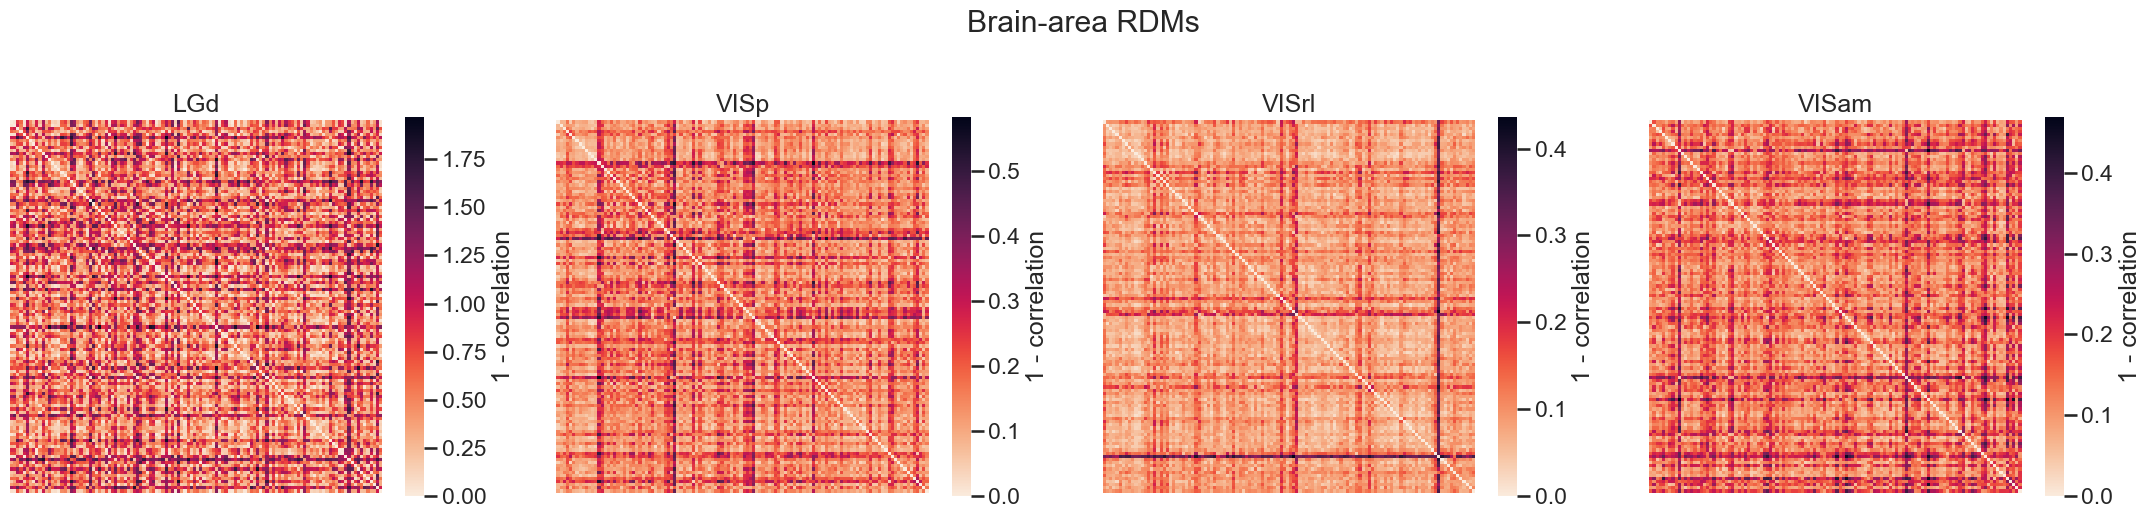

In [29]:
fig, axes = plt.subplots(1, len(area_names), figsize=(5.5 * len(area_names), 5))

for ax, area in zip(axes, area_names):
    sns.heatmap(area_rdms[area], ax=ax, cmap="rocket_r", square=True, cbar_kws={"label": "1 - correlation"}, xticklabels=False, yticklabels=False)
    ax.set_title(area)
fig.suptitle("Brain-area RDMs", y=1.05)
plt.tight_layout()
plt.show()

## Visualize a sample of AlexNet layer RDMs

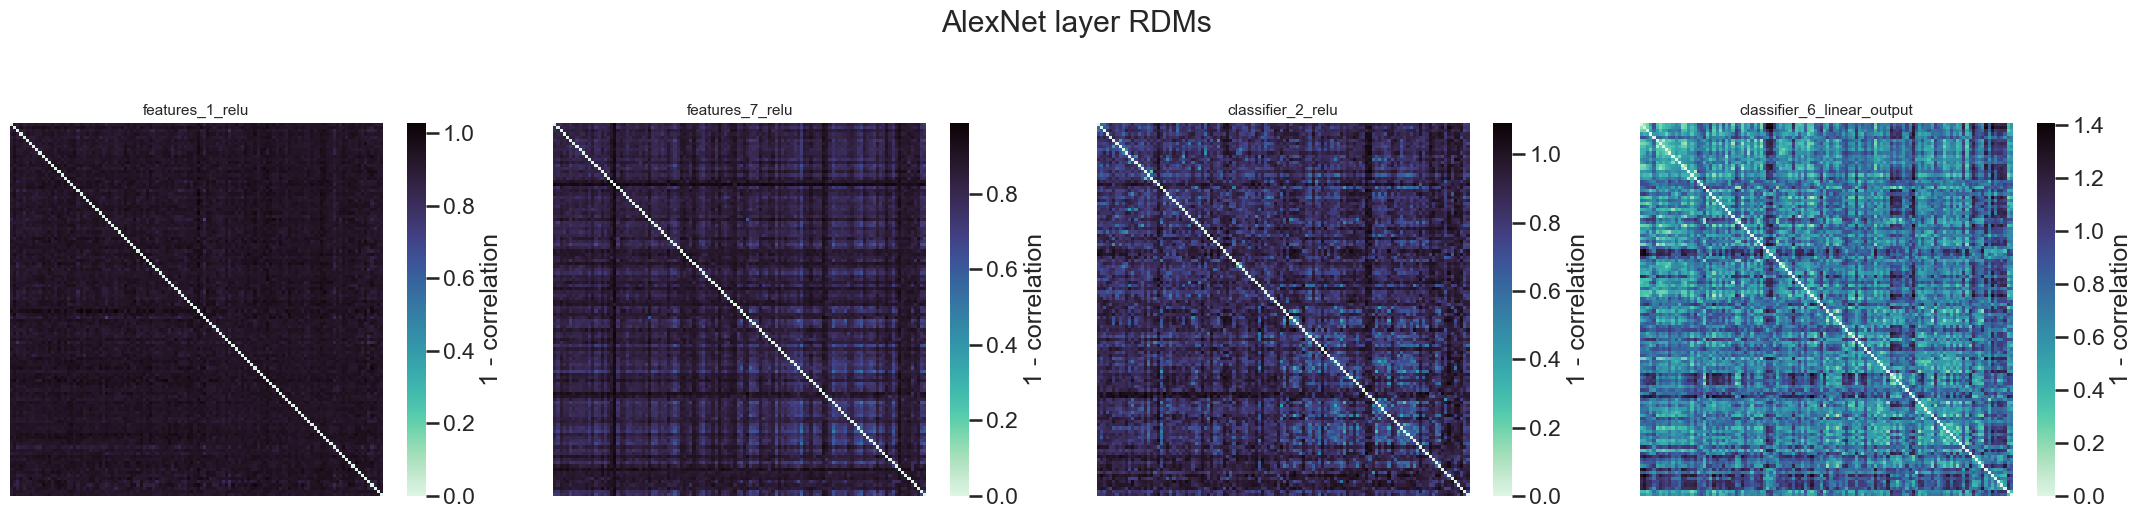

In [31]:
sample_layers = [layer_names[0], layer_names[len(layer_names)//3], layer_names[2*len(layer_names)//3], layer_names[-1]]
fig, axes = plt.subplots(1, len(sample_layers), figsize=(5.5 * len(sample_layers), 5))

for ax, layer in zip(axes, sample_layers):
    sns.heatmap(layer_rdms[layer], ax=ax, cmap="mako_r", square=True, cbar_kws={"label": "1 - correlation"}, xticklabels=False, yticklabels=False)
    ax.set_title(layer, fontsize=11)
    
fig.suptitle("AlexNet layer RDMs", y=1.05)
plt.tight_layout()
plt.show()

## Compare RDMs: layer x area similarity matrix

In [32]:
def upper_triangle(rdm):
    n = rdm.shape[0]
    iu = np.triu_indices(n, k=1)
    return rdm[iu]


def rsa_compare(rdm_a, rdm_b):
    vec_a = upper_triangle(rdm_a)
    vec_b = upper_triangle(rdm_b)
    rho, _ = spearmanr(vec_a, vec_b)
    return rho


similarity = pd.DataFrame(index=layer_names, columns=area_names, dtype=float)
for layer in layer_names:
    for area in area_names:
        similarity.loc[layer, area] = rsa_compare(layer_rdms[layer], area_rdms[area])

similarity

,LGd,VISp,VISrl,VISam
features_1_relu,0.037142,0.156725,0.146068,0.161546
features_4_relu,0.119759,0.192019,0.286629,0.075744
features_7_relu,0.109832,0.138934,0.293961,0.099236
features_9_relu,0.092689,0.094870,0.231480,0.108227
features_11_relu,0.078726,0.111313,0.209909,0.135551
classifier_2_relu,0.084813,0.103827,0.190149,0.135681
classifier_5_relu,0.081369,0.102165,0.161276,0.107867
classifier_6_linear_output,0.045171,0.054623,0.152629,0.103314


## Similarity heatmap: every layer x every area

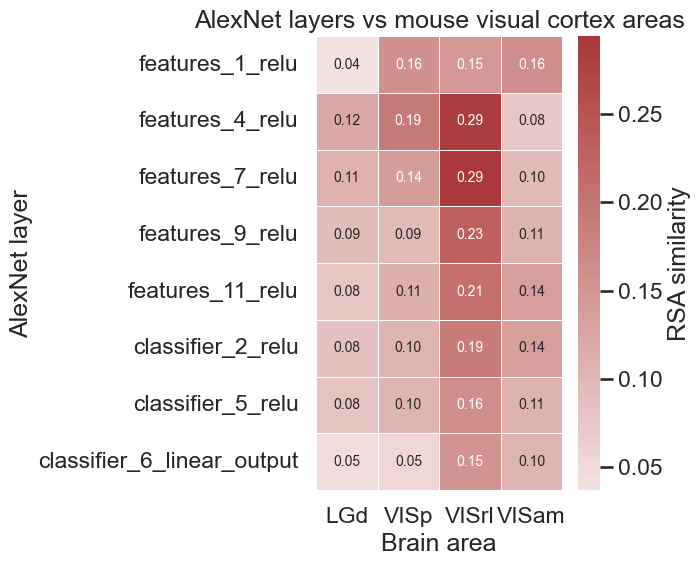

In [34]:
fig, ax = plt.subplots(figsize=(7, max(6, 0.5 * len(layer_names))))
sns.heatmap(similarity.astype(float), annot=True, fmt=".2f", cmap="vlag", center=0, cbar_kws={"label": "RSA similarity"}, ax=ax, annot_kws={"size": 10}, linewidths=0.5, linecolor="white")

ax.set_xlabel("Brain area")
ax.set_ylabel("AlexNet layer")
ax.set_title("AlexNet layers vs mouse visual cortex areas")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Similarity per area across network depth

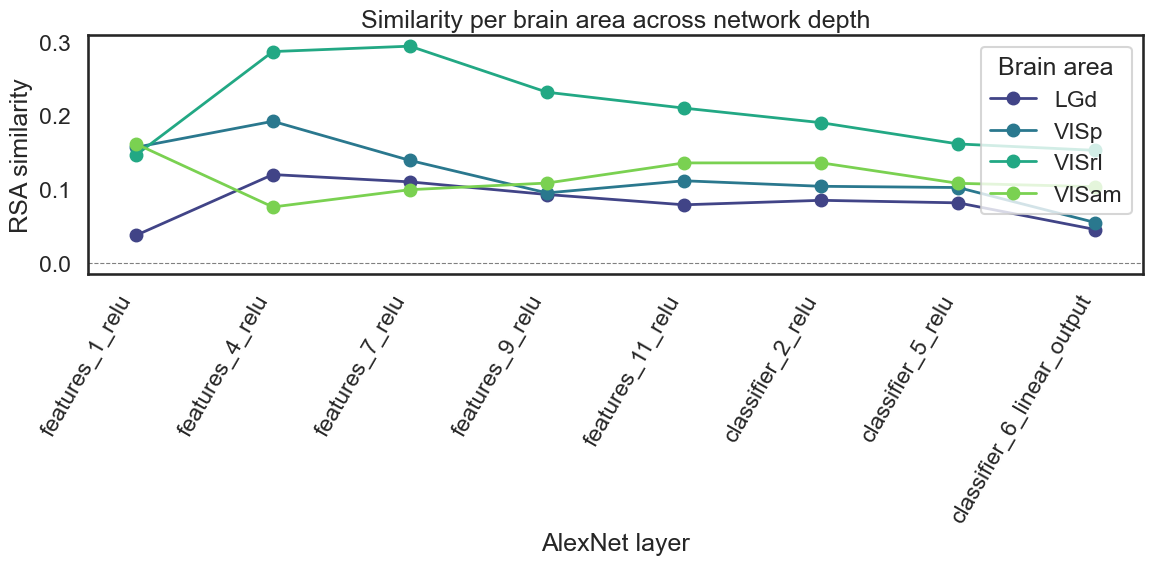

In [35]:
layer_positions = np.arange(len(layer_names))

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette("viridis", n_colors=len(area_names))
for area, color in zip(area_names, palette):
    ax.plot(layer_positions, similarity[area].values, marker="o", label=area, color=color, linewidth=2)

ax.set_xticks(layer_positions)
ax.set_xticklabels(layer_names, rotation=60, ha="right")
ax.set_ylabel("RSA similarity")
ax.set_xlabel("AlexNet layer")
ax.set_title("Similarity per brain area across network depth")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.legend(title="Brain area")
plt.tight_layout()
plt.show()

## Best-matching layer per area

In [36]:
best_layer_per_area = similarity.idxmax(axis=0)
best_score_per_area = similarity.max(axis=0)

summary = pd.DataFrame({"best_matching_layer": best_layer_per_area, "similarity": best_score_per_area, "layer_depth_rank": [layer_names.index(l) for l in best_layer_per_area]})
summary = summary.sort_values("layer_depth_rank")
summary

,best_matching_layer,similarity,layer_depth_rank
VISam,features_1_relu,0.161546,0
LGd,features_4_relu,0.119759,1
VISp,features_4_relu,0.192019,1
VISrl,features_7_relu,0.293961,2


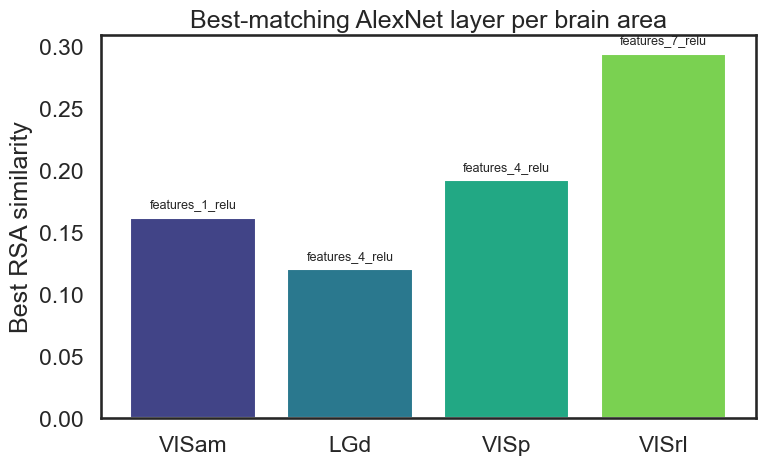

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(summary.index, summary["similarity"], color=sns.color_palette("viridis", n_colors=len(summary)))

for bar, layer in zip(bars, summary["best_matching_layer"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, layer, ha="center", va="bottom", fontsize=9, rotation=0)

ax.set_ylabel("Best RSA similarity")
ax.set_title("Best-matching AlexNet layer per brain area")
plt.tight_layout()
plt.show()

## Statistical significance via permutation test

In [38]:
def permutation_test(rdm_a, rdm_b, n_permutations=5000, seed=0):
    rng = np.random.default_rng(seed)
    observed = rsa_compare(rdm_a, rdm_b)

    n = rdm_b.shape[0]
    null_scores = np.empty(n_permutations)
    for i in range(n_permutations):
        perm = rng.permutation(n)
        shuffled_rdm_b = rdm_b[np.ix_(perm, perm)]
        null_scores[i] = rsa_compare(rdm_a, shuffled_rdm_b)

    p_value = np.mean(null_scores >= observed)
    return observed, null_scores, p_value

In [40]:
permutation_results = {}
for area in area_names:
    best_layer = summary.loc[area, "best_matching_layer"]
    observed, null_scores, p_value = permutation_test(layer_rdms[best_layer], area_rdms[area])
    permutation_results[area] = {"observed": observed, "null_scores": null_scores, "p_value": p_value}
    print(f"{area} - best layer: {best_layer} similarity={observed}  p={p_value}")

LGd - best layer: features_4_relu similarity=0.11975859479086402  p=0.0194
VISp - best layer: features_4_relu similarity=0.19201910208278367  p=0.0016
VISrl - best layer: features_7_relu similarity=0.29396128333164667  p=0.0
VISam - best layer: features_1_relu similarity=0.16154589450655024  p=0.0


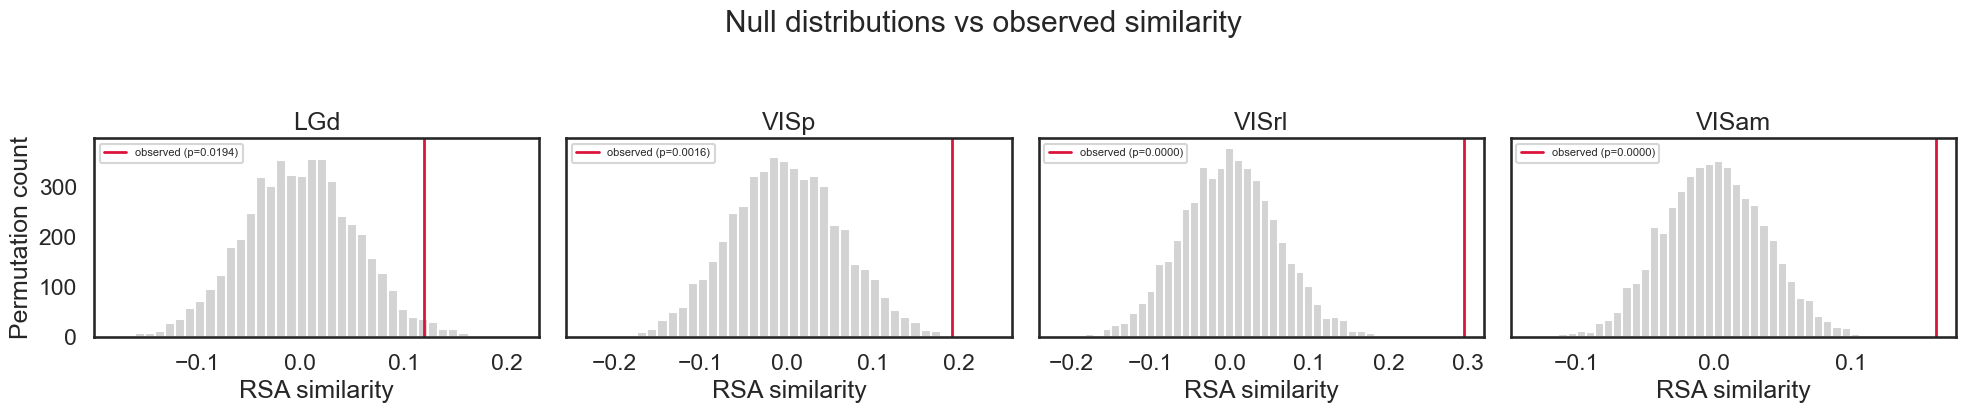

In [42]:
fig, axes = plt.subplots(1, len(area_names), figsize=(5 * len(area_names), 4), sharey=True)
for ax, area in zip(axes, area_names):
    res = permutation_results[area]
    ax.hist(res["null_scores"], bins=40, color="lightgray", edgecolor="white")
    ax.axvline(res["observed"], color="crimson", linewidth=2, label=f"observed (p={res['p_value']:.4f})")
    ax.set_title(area)
    ax.set_xlabel("RSA similarity")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Permutation count")
fig.suptitle("Null distributions vs observed similarity", y=1.05)
plt.tight_layout()
plt.show()

## Save all results

In [43]:
results = {
    "layer_rdms": layer_rdms,
    "area_rdms": area_rdms,
    "similarity_matrix": similarity,
    "best_match_summary": summary,
    "permutation_results": permutation_results,
    "all_names": all_names,
}

with open("rsa_results.pkl", "wb") as f:
    pickle.dump(results, f)